# Bibliotecas

In [32]:
from __future__ import annotations

import sys
import os
import csv
import random
import tempfile
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.utils import make_grid, save_image

from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance

# REPRODUTIBILIDADE

In [49]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

print("=" * 60)
print("Reprodutibilidade configurada")
print(f"Seed base: {SEED}")
print("=" * 60)

Reprodutibilidade configurada
Seed base: 42


# PATHS DO PROJETO

In [50]:
PROJECT_ROOT = Path("..").resolve()
SCRIPTS_DIR = PROJECT_ROOT / "scripts"
KAGGLE_ROOT = PROJECT_ROOT / "ArtBench-10"

print("PROJECT_ROOT =", PROJECT_ROOT)
print("SCRIPTS_DIR  =", SCRIPTS_DIR)
print("KAGGLE_ROOT  =", KAGGLE_ROOT)

if not KAGGLE_ROOT.exists():
    raise FileNotFoundError(f"Não encontrei a pasta do dataset: {KAGGLE_ROOT}")

if not (SCRIPTS_DIR / "artbench_local_dataset.py").exists():
    raise FileNotFoundError(
        f"Não encontrei o ficheiro artbench_local_dataset.py em {SCRIPTS_DIR}"
    )

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

print("Paths configurados com sucesso.")

PROJECT_ROOT = C:\Users\llara\OneDrive\Área de Trabalho\Universidade\Mestrado\Primeiro ano\Segundo Semestre\Inteligência Artificial Generativa\IAG
SCRIPTS_DIR  = C:\Users\llara\OneDrive\Área de Trabalho\Universidade\Mestrado\Primeiro ano\Segundo Semestre\Inteligência Artificial Generativa\IAG\scripts
KAGGLE_ROOT  = C:\Users\llara\OneDrive\Área de Trabalho\Universidade\Mestrado\Primeiro ano\Segundo Semestre\Inteligência Artificial Generativa\IAG\ArtBench-10
Paths configurados com sucesso.


# CARREGAR O DATASET

In [34]:
from artbench_local_dataset import load_kaggle_artbench10_splits

print("=" * 60)
print("A carregar o ArtBench-10...")
print("=" * 60)

hf_ds = load_kaggle_artbench10_splits(KAGGLE_ROOT)

train_hf = hf_ds["train"]
test_hf = hf_ds["test"]

print("Train size:", len(train_hf))
print("Test size :", len(test_hf))
print("Columns   :", train_hf.column_names)

label_feature = train_hf.features["label"]
class_names = list(label_feature.names)
num_classes = len(class_names)

print("Número de classes:", num_classes)
print("Classes:", class_names)

C:\Users\llara\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


A carregar o ArtBench-10...
Dataset source: kaggle root='C:\Users\llara\OneDrive\Área de Trabalho\Universidade\Mestrado\Primeiro ano\Segundo Semestre\Inteligência Artificial Generativa\IAG\ArtBench-10'
Train size: 50000
Test size : 10000
Columns   : ['image', 'label']
Número de classes: 10
Classes: ['impressionism', 'realism', 'romanticism', 'expressionism', 'baroque', 'post_impressionism', 'art_nouveau', 'surrealism', 'ukiyo_e', 'renaissance']


# DISTRIBUIÇÃO DAS CLASSES

In [35]:
train_counts = Counter(train_hf["label"])

print("=" * 60)
print("Distribuição das classes no treino")
print("=" * 60)

for cid, name in enumerate(class_names):
    print(f"{cid:2d} | {name:>15s} | {train_counts.get(cid, 0):6d}")

Distribuição das classes no treino
 0 |   impressionism |   5000
 1 |         realism |   5000
 2 |     romanticism |   5000
 3 |   expressionism |   5000
 4 |         baroque |   5000
 5 | post_impressionism |   5000
 6 |     art_nouveau |   5000
 7 |      surrealism |   5000
 8 |         ukiyo_e |   5000
 9 |     renaissance |   5000


# CONFIGURAÇÃO DE IMAGEM E DATALOADER

In [36]:
IMAGE_SIZE = 32
BATCH_SIZE = 64
NUM_WORKERS = 2
TRAIN_FRACTION = 1.0

def resolve_num_workers(requested: int) -> int:
    if "ipykernel" in sys.modules and int(requested) > 0:
        print("Notebook detetado: num_workers será forçado para 0.")
        return 0
    return int(requested)

EFFECTIVE_NUM_WORKERS = resolve_num_workers(NUM_WORKERS)

transform = T.Compose([
    T.Resize(IMAGE_SIZE, interpolation=T.InterpolationMode.BILINEAR),
    T.CenterCrop(IMAGE_SIZE),
    T.ToTensor()
])

print("=" * 60)
print("Configuração dos dados")
print(f"IMAGE_SIZE = {IMAGE_SIZE}")
print(f"BATCH_SIZE = {BATCH_SIZE}")
print(f"NUM_WORKERS pedido = {NUM_WORKERS}")
print(f"NUM_WORKERS efetivo = {EFFECTIVE_NUM_WORKERS}")
print("=" * 60)


class ArtBenchTorchDataset(Dataset):
    def __init__(self, hf_split, transform=None, indices=None):
        self.ds = hf_split
        self.transform = transform
        self.indices = list(range(len(hf_split))) if indices is None else list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        original_idx = self.indices[idx]
        sample = self.ds[original_idx]
        image = sample["image"]
        label = int(sample["label"])
        x = self.transform(image) if self.transform else image
        return x, label, original_idx


def build_fraction_indices(n_total: int, fraction: float, seed: int = 42):
    n_keep = max(1, int(round(n_total * fraction)))
    rng = np.random.RandomState(seed)
    idx = np.arange(n_total)
    rng.shuffle(idx)
    return idx[:n_keep].tolist()


train_indices = build_fraction_indices(len(train_hf), TRAIN_FRACTION, seed=SEED)

train_ds = ArtBenchTorchDataset(train_hf, transform=transform, indices=train_indices)
test_ds = ArtBenchTorchDataset(test_hf, transform=transform)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("Train dataset length:", len(train_ds))
print("Test dataset length :", len(test_ds))
print("Train batches       :", len(train_loader))
print("Test batches        :", len(test_loader))

Notebook detetado: num_workers será forçado para 0.
Configuração dos dados
IMAGE_SIZE = 32
BATCH_SIZE = 64
NUM_WORKERS pedido = 2
NUM_WORKERS efetivo = 0
Train dataset length: 50000
Test dataset length : 10000
Train batches       : 782
Test batches        : 157


# SUBSET DE TREINO A PARTIR DO CSV

In [37]:
TRAINING_CSV_PATH = Path("training_20_percent.csv")
INDEX_COLUMN = "train_id_original"

def load_ids_from_training_csv(csv_path: Path, index_column: str = "train_id_original") -> list[int]:
    csv_path = Path(csv_path)

    if not csv_path.exists():
        raise FileNotFoundError(
            f"Não encontrei o CSV do subset: {csv_path}"
        )

    ids = []
    with open(csv_path, "r", encoding="utf-8", newline="") as f:
        reader = csv.DictReader(f)

        if index_column not in (reader.fieldnames or []):
            raise ValueError(
                f"A coluna {index_column!r} não existe. Colunas disponíveis: {reader.fieldnames}"
            )

        for row in reader:
            value = str(row.get(index_column, "")).strip()
            if value != "":
                ids.append(int(value))

    if len(ids) == 0:
        raise ValueError("O CSV foi lido, mas não continha IDs válidos.")

    return ids


subset_ids = load_ids_from_training_csv(TRAINING_CSV_PATH, index_column=INDEX_COLUMN)

subset_train_ds = ArtBenchTorchDataset(train_hf, transform=transform, indices=subset_ids)
subset_train_loader = DataLoader(
    subset_train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("=" * 60)
print("Subset de treino carregado")
print(f"Número de IDs no CSV: {len(subset_ids)}")
print(f"Tamanho do dataset subset: {len(subset_train_ds)}")
print(f"Número de batches subset : {len(subset_train_loader)}")
print("=" * 60)

Subset de treino carregado
Número de IDs no CSV: 10000
Tamanho do dataset subset: 10000
Número de batches subset : 157


# VISUALIZAÇÃO DE EXEMPLOS

In [ ]:
def show_batch_grid(loader, class_names, n_images=36, nrow=6, title="Sample Grid"):
    x, y, idx = next(iter(loader))
    x = x[:n_images]
    y = y[:n_images]

    grid = make_grid(x, nrow=nrow, padding=2)
    np_img = grid.permute(1, 2, 0).cpu().numpy()

    plt.figure(figsize=(8, 8))
    plt.imshow(np_img)
    plt.axis("off")
    plt.title(title)
    plt.show()

    labels_str = [class_names[int(v)] for v in y]
    print("Labels:", labels_str)

show_batch_grid(subset_train_loader, class_names, n_images=36, nrow=6, title="ArtBench-10 subset samples")

In [40]:
# =========================
# MODELO VAE
# =========================

class SimpleVAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten()
        )

        self.fc_mu = nn.Linear(64 * 8 * 8, latent_dim)
        self.fc_logvar = nn.Linear(64 * 8 * 8, latent_dim)

        self.decoder_input = nn.Linear(latent_dim, 64 * 8 * 8)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.decoder_input(z).view(-1, 64, 8, 8)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar


# =========================
# DCGAN
# =========================

class DCGANGenerator(nn.Module):
    def __init__(self, noise_dim=100):
        super().__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(noise_dim, 256, 4, 1, 0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        return self.main(z)


class DCGANDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 3, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, 3, 2, 1),
            nn.LeakyReLU(0.2)
        )

        self.classifier = nn.Linear(256 * 4 * 4, 1)

    def forward(self, x):
        h = self.features(x)
        h = h.view(h.size(0), -1)
        return self.classifier(h).squeeze(1)


# =========================
# TOY DIFFUSION U-NET
# =========================

class TinyUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.down = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.ReLU()
        )
        self.up = nn.Sequential(
            nn.Conv2d(64, 3, 3, padding=1)
        )

    def forward(self, x, t):
        return self.up(self.down(x))

In [41]:
# =========================
# INICIALIZAÇÃO
# =========================

LATENT_DIM = 128
NOISE_DIM = 100
EPOCHS = 10
LR_VAE = 1e-3
LR_GAN = 2e-4
LR_DIFF = 1e-3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vae_model = SimpleVAE(latent_dim=LATENT_DIM).to(device)
gan_generator = DCGANGenerator(noise_dim=NOISE_DIM).to(device)
gan_discriminator = DCGANDiscriminator().to(device)
diffusion_model = TinyUNet().to(device)

print("=" * 60)
print("Modelos instanciados")
print(f"Device: {device}")
print("=" * 60)

vae_optimizer = torch.optim.Adam(vae_model.parameters(), lr=LR_VAE)
gan_g_optimizer = torch.optim.Adam(gan_generator.parameters(), lr=LR_GAN, betas=(0.5, 0.999))
gan_d_optimizer = torch.optim.Adam(gan_discriminator.parameters(), lr=LR_GAN, betas=(0.5, 0.999))
diff_optimizer = torch.optim.Adam(diffusion_model.parameters(), lr=LR_DIFF)

gan_criterion = nn.BCEWithLogitsLoss()

T_STEPS = 100
betas = torch.linspace(1e-4, 0.02, T_STEPS, device=device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

Modelos instanciados
Device: cpu


In [42]:
def vae_loss_function(recon_x, x, mu, logvar):
    recon_loss = F.mse_loss(recon_x, x, reduction="sum")
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_div


def to_01(x):
    x = x.detach().cpu()
    if x.min() < 0:
        x = (x + 1.0) / 2.0
    return x.clamp(0, 1)


def to_uint8(x):
    x = to_01(x)
    return (x * 255.0).round().to(torch.uint8)

In [43]:
def train_vae(model, loader, optimizer, epochs, device):
    history = []

    print("=" * 60)
    print("Treino do VAE")
    print("=" * 60)

    model.train()

    for epoch in range(epochs):
        running_loss = 0.0

        for batch_idx, (real_imgs, labels, indices) in enumerate(loader):
            real_imgs = real_imgs.to(device)

            optimizer.zero_grad()
            recon_imgs, mu, logvar = model(real_imgs)
            loss = vae_loss_function(recon_imgs, real_imgs, mu, logvar)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(loader.dataset)
        history.append(epoch_loss)

        print(f"[VAE] Epoch {epoch + 1}/{epochs} | loss = {epoch_loss:.6f}")

    return history

In [44]:
def train_vae(model, loader, optimizer, epochs, device):
    history = []

    print("=" * 60)
    print("Treino do VAE")
    print("=" * 60)

    model.train()

    for epoch in range(epochs):
        running_loss = 0.0

        for batch_idx, (real_imgs, labels, indices) in enumerate(loader):
            real_imgs = real_imgs.to(device)

            optimizer.zero_grad()
            recon_imgs, mu, logvar = model(real_imgs)
            loss = vae_loss_function(recon_imgs, real_imgs, mu, logvar)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(loader.dataset)
        history.append(epoch_loss)

        print(f"[VAE] Epoch {epoch + 1}/{epochs} | loss = {epoch_loss:.6f}")

    return history

In [45]:
def train_gan(generator, discriminator, loader, opt_g, opt_d, criterion, epochs, device, noise_dim=100):
    g_history = []
    d_history = []

    print("=" * 60)
    print("Treino da DCGAN")
    print("=" * 60)

    generator.train()
    discriminator.train()

    for epoch in range(epochs):
        epoch_g_loss = 0.0
        epoch_d_loss = 0.0

        for batch_idx, (real_imgs, labels, indices) in enumerate(loader):
            real_imgs = real_imgs.to(device)
            batch_size = real_imgs.size(0)

            real_targets = torch.ones(batch_size, device=device)
            fake_targets = torch.zeros(batch_size, device=device)

            # ---------
            # Train D
            # ---------
            opt_d.zero_grad()

            real_logits = discriminator(real_imgs)
            d_loss_real = criterion(real_logits, real_targets)

            noise = torch.randn(batch_size, noise_dim, 1, 1, device=device)
            fake_imgs = generator(noise)
            fake_logits = discriminator(fake_imgs.detach())
            d_loss_fake = criterion(fake_logits, fake_targets)

            d_loss = d_loss_real + d_loss_fake
            d_loss.backward()
            opt_d.step()

            # ---------
            # Train G
            # ---------
            opt_g.zero_grad()

            noise = torch.randn(batch_size, noise_dim, 1, 1, device=device)
            fake_imgs = generator(noise)
            fake_logits = discriminator(fake_imgs)

            g_loss = criterion(fake_logits, real_targets)
            g_loss.backward()
            opt_g.step()

            epoch_d_loss += d_loss.item()
            epoch_g_loss += g_loss.item()

        avg_d = epoch_d_loss / len(loader)
        avg_g = epoch_g_loss / len(loader)

        d_history.append(avg_d)
        g_history.append(avg_g)

        print(f"[GAN] Epoch {epoch + 1}/{epochs} | D loss = {avg_d:.6f} | G loss = {avg_g:.6f}")

    return g_history, d_history

In [46]:
def train_diffusion(model, loader, optimizer, epochs, device, betas, alphas_cumprod):
    history = []

    print("=" * 60)
    print("Treino do modelo de difusão")
    print("=" * 60)

    model.train()
    n_steps = betas.size(0)

    for epoch in range(epochs):
        running_loss = 0.0

        for batch_idx, (real_imgs, labels, indices) in enumerate(loader):
            real_imgs = real_imgs.to(device)
            batch_size = real_imgs.size(0)

            t = torch.randint(0, n_steps, (batch_size,), device=device)
            noise = torch.randn_like(real_imgs)

            alpha_bar_t = alphas_cumprod[t].view(-1, 1, 1, 1)
            noisy_imgs = torch.sqrt(alpha_bar_t) * real_imgs + torch.sqrt(1 - alpha_bar_t) * noise

            pred_noise = model(noisy_imgs, t)
            loss = F.mse_loss(pred_noise, noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(loader)
        history.append(epoch_loss)

        print(f"[Diffusion] Epoch {epoch + 1}/{epochs} | loss = {epoch_loss:.6f}")

    return history

In [47]:
vae_history = train_vae(
    model=vae_model,
    loader=subset_train_loader,
    optimizer=vae_optimizer,
    epochs=EPOCHS,
    device=device
)

gan_g_history, gan_d_history = train_gan(
    generator=gan_generator,
    discriminator=gan_discriminator,
    loader=subset_train_loader,
    opt_g=gan_g_optimizer,
    opt_d=gan_d_optimizer,
    criterion=gan_criterion,
    epochs=EPOCHS,
    device=device,
    noise_dim=NOISE_DIM
)

diff_history = train_diffusion(
    model=diffusion_model,
    loader=subset_train_loader,
    optimizer=diff_optimizer,
    epochs=EPOCHS,
    device=device,
    betas=betas,
    alphas_cumprod=alphas_cumprod
)

Treino do VAE
[VAE] Epoch 1/10 | loss = 120.985298
[VAE] Epoch 2/10 | loss = 92.373080
[VAE] Epoch 3/10 | loss = 80.871680
[VAE] Epoch 4/10 | loss = 75.795837
[VAE] Epoch 5/10 | loss = 73.847207
[VAE] Epoch 6/10 | loss = 72.543404
[VAE] Epoch 7/10 | loss = 71.972592
[VAE] Epoch 8/10 | loss = 71.538084
[VAE] Epoch 9/10 | loss = 71.114903
[VAE] Epoch 10/10 | loss = 71.004149
Treino da DCGAN
[GAN] Epoch 1/10 | D loss = 1.150582 | G loss = 1.147521
[GAN] Epoch 2/10 | D loss = 1.319031 | G loss = 0.850233
[GAN] Epoch 3/10 | D loss = 1.389226 | G loss = 0.724923
[GAN] Epoch 4/10 | D loss = 1.365724 | G loss = 0.742937
[GAN] Epoch 5/10 | D loss = 1.380151 | G loss = 0.730923
[GAN] Epoch 6/10 | D loss = 1.383346 | G loss = 0.745427
[GAN] Epoch 7/10 | D loss = 1.372313 | G loss = 0.760640
[GAN] Epoch 8/10 | D loss = 1.382061 | G loss = 0.752984
[GAN] Epoch 9/10 | D loss = 1.366695 | G loss = 0.779258
[GAN] Epoch 10/10 | D loss = 1.365904 | G loss = 0.779585
Treino do modelo de difusão
[Diffusio

In [51]:
def collect_real_images(loader, n_samples=5000):
    print(f"[Real] A recolher {n_samples} imagens reais...")

    images = []
    total = 0

    for batch_idx, batch in enumerate(loader):
        x = batch[0]
        images.append(to_uint8(x))
        total += x.size(0)

        print(f"  Batch {batch_idx + 1}: acumuladas = {total}")

        if total >= n_samples:
            break

    images = torch.cat(images, dim=0)[:n_samples]
    print(f"[Real] Shape final: {images.shape}")
    return images

In [52]:
@torch.no_grad()
def sample_from_vae(model, n_samples=5000, latent_dim=128, batch_size=256, device="cpu"):
    print(f"[VAE] A gerar {n_samples} imagens...")
    model.eval()

    outputs = []
    generated = 0

    while generated < n_samples:
        current_bs = min(batch_size, n_samples - generated)
        z = torch.randn(current_bs, latent_dim, device=device)

        x = model.decode(z)
        outputs.append(to_uint8(x))

        generated += current_bs
        print(f"  [VAE] Geradas: {generated}/{n_samples}")

    samples = torch.cat(outputs, dim=0)[:n_samples]
    print(f"[VAE] Shape final: {samples.shape}")
    return samples

In [53]:
@torch.no_grad()
def sample_from_gan(generator, n_samples=5000, noise_dim=100, batch_size=256, device="cpu"):
    print(f"[GAN] A gerar {n_samples} imagens...")
    generator.eval()

    outputs = []
    generated = 0

    while generated < n_samples:
        current_bs = min(batch_size, n_samples - generated)
        z = torch.randn(current_bs, noise_dim, 1, 1, device=device)
        x = generator(z)

        outputs.append(to_uint8(x))

        generated += current_bs
        print(f"  [GAN] Geradas: {generated}/{n_samples}")

    samples = torch.cat(outputs, dim=0)[:n_samples]
    print(f"[GAN] Shape final: {samples.shape}")
    return samples

In [54]:
@torch.no_grad()
def sample_from_diffusion(model, n_samples=5000, img_size=32, channels=3, batch_size=128, device="cpu"):
    print(f"[Diffusion] A gerar {n_samples} imagens...")
    model.eval()

    outputs = []

    alpha = 1.0 - betas
    alpha_bar = torch.cumprod(alpha, dim=0)

    generated = 0

    while generated < n_samples:
        current_bs = min(batch_size, n_samples - generated)

        x = torch.randn(current_bs, channels, img_size, img_size, device=device)

        for t in reversed(range(T_STEPS)):
            tt = torch.full((current_bs,), t, device=device, dtype=torch.long)
            pred_noise = model(x, tt)

            a_t = alpha[t]
            ab_t = alpha_bar[t]
            b_t = betas[t]

            if t > 0:
                z = torch.randn_like(x)
            else:
                z = torch.zeros_like(x)

            x = (1 / torch.sqrt(a_t)) * (
                x - ((1 - a_t) / torch.sqrt(1 - ab_t)) * pred_noise
            ) + torch.sqrt(b_t) * z

        outputs.append(to_uint8(x))

        generated += current_bs
        print(f"  [Diffusion] Geradas: {generated}/{n_samples}")

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    samples = torch.cat(outputs, dim=0)[:n_samples]
    print(f"[Diffusion] Shape final: {samples.shape}")
    return samples

In [55]:
def show_generated_grid(images_uint8, title, n=36, nrow=6):
    x = images_uint8[:n].float() / 255.0
    grid = make_grid(x, nrow=nrow, padding=2)

    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.axis("off")
    plt.title(title)
    plt.show()

In [56]:
def compute_fid_kid(real_uint8, fake_uint8, kid_subsets=50, kid_subset_size=100, device="cpu"):
    print("[Metrics] A calcular FID e KID...")

    fid_metric = FrechetInceptionDistance(feature=2048, normalize=False).to(device)
    kid_metric = KernelInceptionDistance(
        feature=2048,
        subsets=kid_subsets,
        subset_size=kid_subset_size,
        normalize=False
    ).to(device)

    real = real_uint8.to(device)
    fake = fake_uint8.to(device)

    fid_metric.update(real, real=True)
    fid_metric.update(fake, real=False)
    fid_value = float(fid_metric.compute().cpu())

    kid_metric.update(real, real=True)
    kid_metric.update(fake, real=False)
    kid_mean, kid_std = kid_metric.compute()

    kid_mean = float(kid_mean.cpu())
    kid_std = float(kid_std.cpu())

    print(f"[Metrics] FID = {fid_value:.4f}")
    print(f"[Metrics] KID mean = {kid_mean:.6f}")
    print(f"[Metrics] KID std  = {kid_std:.6f}")

    return fid_value, kid_mean, kid_std

[Real] A recolher 32 imagens reais...
  Batch 1: acumuladas = 64
[Real] Shape final: torch.Size([32, 3, 32, 32])
[VAE] A gerar 32 imagens...
  [VAE] Geradas: 32/32
[VAE] Shape final: torch.Size([32, 3, 32, 32])
[GAN] A gerar 32 imagens...
  [GAN] Geradas: 32/32
[GAN] Shape final: torch.Size([32, 3, 32, 32])
[Diffusion] A gerar 16 imagens...
  [Diffusion] Geradas: 8/16
  [Diffusion] Geradas: 16/16
[Diffusion] Shape final: torch.Size([16, 3, 32, 32])


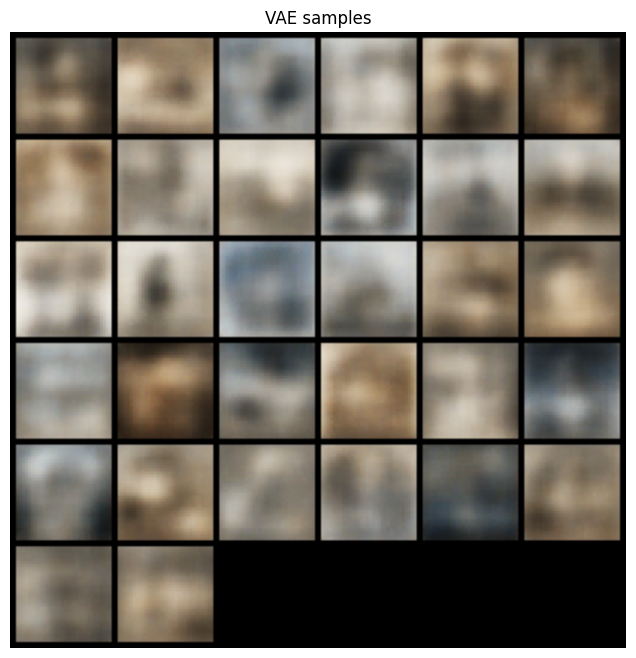

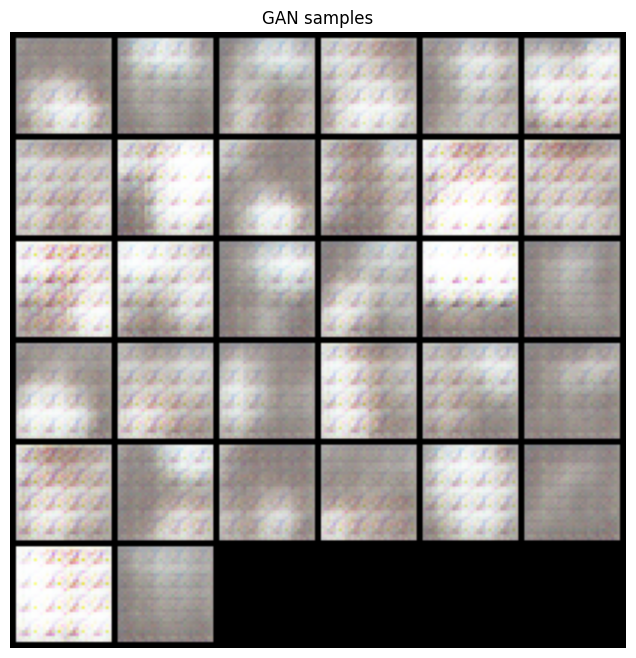

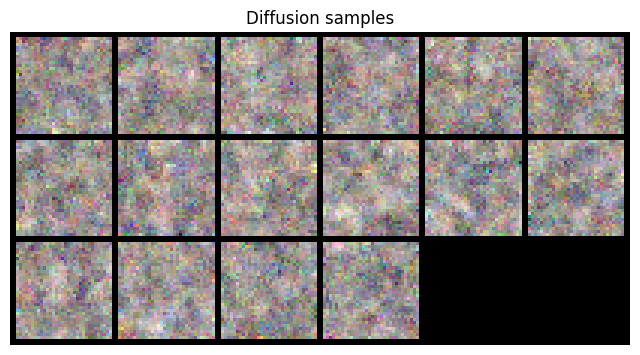

In [57]:
real_test = collect_real_images(test_loader, n_samples=32)

vae_test = sample_from_vae(vae_model, n_samples=32, latent_dim=LATENT_DIM, batch_size=32, device=device)
gan_test = sample_from_gan(gan_generator, n_samples=32, noise_dim=NOISE_DIM, batch_size=32, device=device)
diff_test = sample_from_diffusion(diffusion_model, n_samples=16, img_size=32, channels=3, batch_size=8, device=device)

show_generated_grid(vae_test, "VAE samples")
show_generated_grid(gan_test, "GAN samples")
show_generated_grid(diff_test, "Diffusion samples")

In [ ]:
def set_all_seeds(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


N_REPETITIONS = 10
N_EVAL_SAMPLES = 5000

results = {
    "VAE": {"fid": [], "kid_mean": [], "kid_std": []},
    "DCGAN": {"fid": [], "kid_mean": [], "kid_std": []},
    "Diffusion": {"fid": [], "kid_mean": [], "kid_std": []},
}

print("=" * 70)
print("INÍCIO DO PROTOCOLO OFICIAL DE AVALIAÇÃO")
print("=" * 70)

real_5000 = collect_real_images(test_loader, n_samples=N_EVAL_SAMPLES)

for repetition in range(N_REPETITIONS):
    current_seed = SEED + repetition

    print("\n" + "#" * 70)
    print(f"Repetição {repetition + 1}/{N_REPETITIONS} | seed = {current_seed}")
    print("#" * 70)

    set_all_seeds(current_seed)

    vae_samples = sample_from_vae(
        vae_model,
        n_samples=N_EVAL_SAMPLES,
        latent_dim=LATENT_DIM,
        batch_size=256,
        device=device
    )

    gan_samples = sample_from_gan(
        gan_generator,
        n_samples=N_EVAL_SAMPLES,
        noise_dim=NOISE_DIM,
        batch_size=256,
        device=device
    )

    diff_samples = sample_from_diffusion(
        diffusion_model,
        n_samples=N_EVAL_SAMPLES,
        img_size=32,
        channels=3,
        batch_size=64,
        device=device
    )

    for model_name, fake_imgs in {
        "VAE": vae_samples,
        "DCGAN": gan_samples,
        "Diffusion": diff_samples
    }.items():
        print("\n" + "-" * 50)
        print(f"A avaliar: {model_name}")
        print("-" * 50)

        fid_value, kid_mean, kid_std = compute_fid_kid(
            real_5000,
            fake_imgs,
            kid_subsets=50,
            kid_subset_size=100,
            device=device
        )

        results[model_name]["fid"].append(fid_value)
        results[model_name]["kid_mean"].append(kid_mean)
        results[model_name]["kid_std"].append(kid_std)

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

print("\nProtocolo concluído.")

INÍCIO DO PROTOCOLO OFICIAL DE AVALIAÇÃO
[Real] A recolher 5000 imagens reais...
  Batch 1: acumuladas = 64
  Batch 2: acumuladas = 128
  Batch 3: acumuladas = 192
  Batch 4: acumuladas = 256
  Batch 5: acumuladas = 320
  Batch 6: acumuladas = 384
  Batch 7: acumuladas = 448
  Batch 8: acumuladas = 512
  Batch 9: acumuladas = 576
  Batch 10: acumuladas = 640
  Batch 11: acumuladas = 704
  Batch 12: acumuladas = 768
  Batch 13: acumuladas = 832
  Batch 14: acumuladas = 896
  Batch 15: acumuladas = 960
  Batch 16: acumuladas = 1024
  Batch 17: acumuladas = 1088
  Batch 18: acumuladas = 1152
  Batch 19: acumuladas = 1216
  Batch 20: acumuladas = 1280
  Batch 21: acumuladas = 1344
  Batch 22: acumuladas = 1408
  Batch 23: acumuladas = 1472
  Batch 24: acumuladas = 1536
  Batch 25: acumuladas = 1600
  Batch 26: acumuladas = 1664
  Batch 27: acumuladas = 1728
  Batch 28: acumuladas = 1792
  Batch 29: acumuladas = 1856
  Batch 30: acumuladas = 1920
  Batch 31: acumuladas = 1984
  Batch 32: ac

C:\Users\llara\AppData\Roaming\Python\Python314\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)
